# Import libraries

In [61]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.model_selection import GridSearchCV

In [123]:
# import the data
titanic_data = pd.read_csv("data/train.csv")
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [124]:
# shape of the data
titanic_data.shape

(891, 12)

In [4]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Exploratory Data Analysis

In [5]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


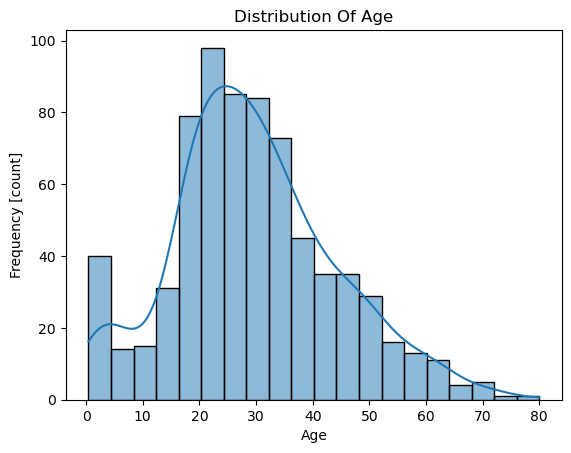

In [130]:
# plot the Age
sns.histplot(
 data=titanic_data,
 x = "Age",
    kde=True
);
plt.xlabel("Age")
plt.ylabel("Frequency [count]")
plt.title("Distribution Of Age")
plt.savefig(
    "figures/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show();


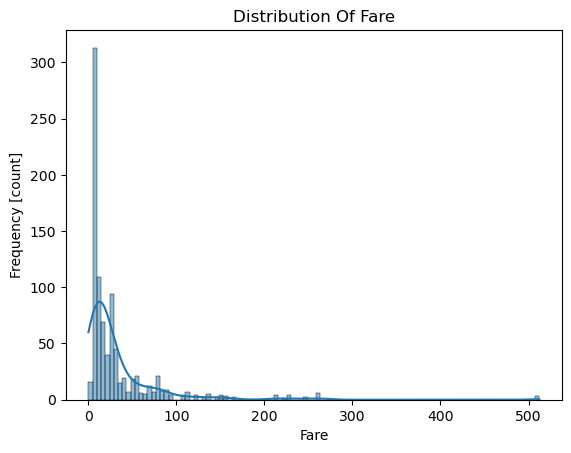

In [131]:
# plot the Age
sns.histplot(
 data=titanic_data,
 x = "Fare",
    kde=True
);
plt.xlabel("Fare")
plt.ylabel("Frequency [count]")
plt.title("Distribution Of Fare")
plt.savefig(
    "figures/fare_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show();


In [8]:
# check correlation
corr_matrix =titanic_data.select_dtypes("number").corr()

In [9]:
corr_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


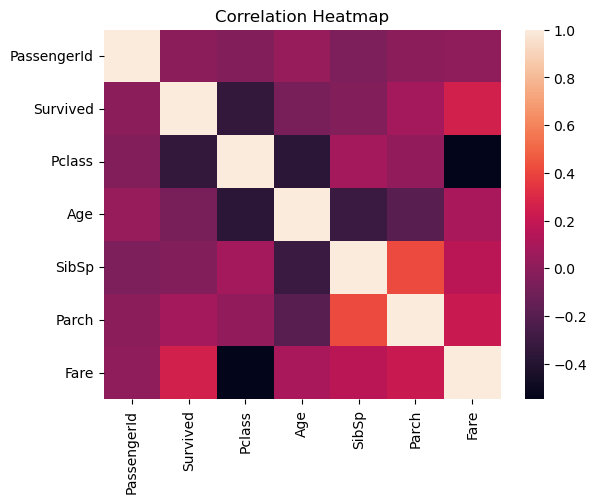

In [132]:
sns.heatmap(corr_matrix)
plt.title("Correlation Heatmap")
plt.savefig(
    "figures/correlation_matrix",
    dpi=300,
    bbox_inches="tight"
)
plt.show();

In [119]:
plt.gcf().savefig(
    "corr_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

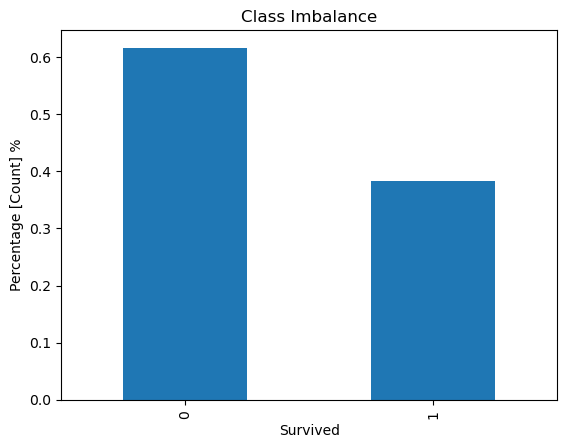

In [133]:
# survived 
titanic_data["Survived"].value_counts(normalize = True).plot(
    kind = "bar"
)
plt.ylabel("Percentage [Count] %")
plt.xlabel("Survived")
plt.title("Class Imbalance")
plt.savefig(
    "figures/class_imbalance.png",
    dpi=300,
    bbox_inches="tight"
);

## Splitting using shuffle split

In [14]:
split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2)
for train_indices, test_indices in split.split(titanic_data, titanic_data[["Survived", "Pclass", "Sex"]]):
    strat_train_set = titanic_data.loc[train_indices]
    strat_test_set = titanic_data.loc[test_indices]

In [16]:
# check the split
print("shape strat train set :", strat_train_set.shape)
print("shape strat test set :", strat_test_set.shape)

shape strat train set : (712, 12)
shape strat test set : (179, 12)


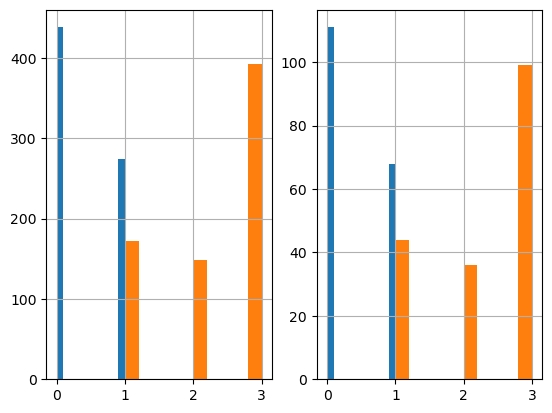

In [134]:
# make a plot
plt.subplot(1,2,1)
strat_train_set["Survived"].hist()
strat_train_set["Pclass"].hist()

plt.subplot(1, 2, 2)
strat_test_set["Survived"].hist()
strat_test_set["Pclass"].hist()
plt.savefig(
    "shuffle_split_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 816 to 156
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          575 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Cabin        165 non-null    object 
 11  Embarked     710 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.3+ KB


# Preprocessing and Pipeline

In [20]:
# Age Imputer
class AgeImputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        self.imputer = SimpleImputer(strategy="mean")
        self.imputer.fit(X[["Age"]])
        return self

    def transform(self, X):
        X = X.copy()
        X["Age"] = self.imputer.transform(X[["Age"]]).ravel()
        return X


# Embarked Imputer
class EmbarkedImputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        self.imputer = SimpleImputer(strategy="most_frequent")
        self.imputer.fit(X[["Embarked"]])
        return self

    def transform(self, X):
        X = X.copy()
        X["Embarked"] = self.imputer.transform(X[["Embarked"]]).ravel()
        return X

# Feature Encoder
class FeatureEncoder(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):

        self.embarked_encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )

        self.sex_encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )

        self.embarked_encoder.fit(X[["Embarked"]])
        self.sex_encoder.fit(X[["Sex"]])

        return self

    def transform(self, X):

        X = X.copy()

        # Encode Embarked
        embarked_matrix = self.embarked_encoder.transform(
            X[["Embarked"]]
        )

        embarked_cols = self.embarked_encoder.get_feature_names_out(
            ["Embarked"]
        )

        embarked_df = pd.DataFrame(
            embarked_matrix,
            columns=embarked_cols,
            index=X.index
        )

        # Encode Sex
        sex_matrix = self.sex_encoder.transform(
            X[["Sex"]]
        )

        sex_cols = self.sex_encoder.get_feature_names_out(
            ["Sex"]
        )

        sex_df = pd.DataFrame(
            sex_matrix,
            columns=sex_cols,
            index=X.index
        )

        # Combine
        X = pd.concat(
            [X, embarked_df, sex_df],
            axis=1
        )

        return X


# Feature Dropper
class FeatureDropper(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        return X.drop(
            columns=[
                "Embarked",
                "Name",
                "Ticket",
                "Cabin",
                "Sex"
            ],
            errors="ignore"
        )


## complete pipeline

In [21]:
# Complete Pipeline
pipeline = Pipeline([
    ("age_imputer", AgeImputer()),
    ("embarked_imputer", EmbarkedImputer()),
    ("feature_encoder", FeatureEncoder()),
    ("feature_dropper", FeatureDropper())
])

# Model Phase

In [34]:
# Baseline prediction
baseline_pred = strat_train_set["Survived"].value_counts(normalize = True).max()
print("The Baseline prediction is :", round(baseline_pred * 100, 2))

The Baseline prediction is : 61.52


In [ ]:
strat_train_set = pipeline.fit_transform(strat_train_set)

In [36]:
strat_train_set.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
816,817,0,3,23.000000,0,0,7.9250,0.0,0.0,1.0,1.0,0.0
814,815,0,3,30.500000,0,0,8.0500,0.0,0.0,1.0,0.0,1.0
104,105,0,3,37.000000,2,0,7.9250,0.0,0.0,1.0,0.0,1.0
300,301,1,3,29.511322,0,0,7.7500,0.0,1.0,0.0,1.0,0.0
248,249,1,1,37.000000,1,1,52.5542,0.0,0.0,1.0,0.0,1.0


In [54]:
# scale the training data
X = strat_train_set.drop(["Survived"], axis=1)
y = strat_train_set["Survived"]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)
y_train_scaled = y.to_numpy()

In [55]:
# check the scaled data
X_train_scaled[:5]

array([[ 1.43927754,  0.82789342, -0.49642499, -0.48588139, -0.48187552,
        -0.53433196, -0.50350881, -0.30058646,  0.63152294,  1.35941164,
        -1.35941164],
       [ 1.4315826 ,  0.82789342,  0.07537711, -0.48588139, -0.48187552,
        -0.53158517, -0.50350881, -0.30058646,  0.63152294, -0.73561236,
         0.73561236],
       [-1.30012022,  0.82789342,  0.57093892,  1.27915713, -0.48187552,
        -0.53433196, -0.50350881, -0.30058646,  0.63152294, -0.73561236,
         0.73561236],
       [-0.54601634,  0.82789342,  0.        , -0.48588139, -0.48187552,
        -0.53817746, -0.50350881,  3.32682981, -1.58347376,  1.35941164,
        -1.35941164],
       [-0.74608471, -1.56828591,  0.57093892,  0.39663787,  0.7522805 ,
         0.44636398, -0.50350881, -0.30058646,  0.63152294, -0.73561236,
         0.73561236]])

In [45]:
# tranform the strat_test_set
strat_test_set = pipeline.fit_transform(strat_test_set)

In [46]:
# scale the training data
X = strat_test_set.drop(["Survived"], axis=1)
y = strat_test_set["Survived"]
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X)
y_test_scaled = y.to_numpy()

In [50]:
# check the scaled data
X_test_scaled[:5]

array([[ 4.95274746e-01,  8.25347166e-01,  1.22161043e-01,
        -4.30058151e-01, -4.40792948e-01, -3.79636278e-01,
        -3.93495501e-01, -3.34366928e-01,  5.53687044e-01,
        -7.46003847e-01,  7.46003847e-01],
       [-2.85891040e-01, -3.66081404e-01,  4.42787647e-01,
        -4.30058151e-01, -4.40792948e-01, -2.99798231e-01,
        -3.93495501e-01, -3.34366928e-01,  5.53687044e-01,
         1.34047566e+00, -1.34047566e+00],
       [-6.23582500e-01,  8.25347166e-01, -2.84773631e-16,
        -4.30058151e-01, -4.40792948e-01, -3.77669824e-01,
        -3.93495501e-01, -3.34366928e-01,  5.53687044e-01,
        -7.46003847e-01,  7.46003847e-01],
       [-1.84822261e+00, -1.55750997e+00,  3.62630996e-01,
         6.10217647e-01, -4.40792948e-01,  3.31040326e-01,
        -3.93495501e-01, -3.34366928e-01,  5.53687044e-01,
         1.34047566e+00, -1.34047566e+00],
       [ 7.63800485e-01, -1.55750997e+00,  1.40466746e+00,
         6.10217647e-01, -4.40792948e-01,  7.02766273e-01,
  

In [58]:
# model dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=2000,
        random_state=42
    )
}

## training and evaluation

In [59]:
# training and evaluating the models
results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train_scaled)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test_scaled, y_pred)

    precision = precision_score(y_test_scaled, y_pred)

    recall = recall_score(y_test_scaled, y_pred)

    f1 = f1_score(y_test_scaled, y_pred)

    results.append(
        {
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        }
    )

In [60]:
# convert the result to a dataframe
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.787709,0.720588,0.720588,0.720588
4,MLP,0.782123,0.730159,0.676471,0.702290
3,SVM,0.782123,0.754386,0.632353,0.688000
2,Random Forest,0.759777,0.711864,0.617647,0.661417
1,Decision Tree,0.709497,0.614286,0.632353,0.623188


### using cross validation

In [77]:
# using the gridsearch Cv
clf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [10, 100, 500, 1000],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_data_scaled, y_data_scaled)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [10, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,1000


In [78]:
best_clf = grid_search.best_estimator_

In [79]:
# check the accuracy
accuracy_clf = best_clf.score(X_test_scaled,y_test_scaled)
accuracy_clf


0.7877094972067039

# Retrain the whole dataset

In [80]:
titanic_data = pipeline.fit_transform(titanic_data)
titanic_data.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,1,0,3,22.0,1,0,7.2500,0.0,0.0,1.0,0.0,1.0
1,2,1,1,38.0,1,0,71.2833,1.0,0.0,0.0,1.0,0.0
2,3,1,3,26.0,0,0,7.9250,0.0,0.0,1.0,1.0,0.0
3,4,1,1,35.0,1,0,53.1000,0.0,0.0,1.0,1.0,0.0
4,5,0,3,35.0,0,0,8.0500,0.0,0.0,1.0,0.0,1.0


In [82]:
# split and scale the data
X_train_final = titanic_data.drop(["Survived"], axis = 1)
y_train_final = titanic_data["Survived"]
scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
y_test_final_scaled = y_train_final.to_numpy()

In [83]:
# review
X_train_final_scaled[:4]


array([[-1.73010796,  0.82737724, -0.5924806 ,  0.43279337, -0.47367361,
        -0.50244517, -0.48204268, -0.30756234,  0.61583843, -0.73769513,
         0.73769513],
       [-1.72622007, -1.56610693,  0.63878901,  0.43279337, -0.47367361,
         0.78684529,  2.0745051 , -0.30756234, -1.62380254,  1.35557354,
        -1.35557354],
       [-1.72233219,  0.82737724, -0.2846632 , -0.4745452 , -0.47367361,
        -0.48885426, -0.48204268, -0.30756234,  0.61583843,  1.35557354,
        -1.35557354],
       [-1.71844431, -1.56610693,  0.40792596,  0.43279337, -0.47367361,
         0.42073024, -0.48204268, -0.30756234,  0.61583843,  1.35557354,
        -1.35557354]])

In [85]:
y_test_final_scaled[:5]

array([0, 1, 1, 1, 0], dtype=int64)

In [88]:
# training and evaluating the final model using Ensemble method models
# using the gridsearch Cv
final_clf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [10, 100, 500, 1000],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 3, 4]
}

grid_search_final = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_search_final.fit(X_train_final_scaled, y_test_final_scaled)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [10, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,1000


In [89]:
prod_clf_model = grid_search_final.best_estimator_

In [90]:
# import the final test data
final_test_data = pd.read_csv("data/test.csv")
# transform the data using the pipeline
final_test_data = pipeline.fit_transform(final_test_data)
# scale the data
scaler = StandardScaler()
final_test_data_scaled =scaler.fit_transform(final_test_data)


In [91]:
# make prediction
prediction = prod_clf_model.predict(final_test_data_scaled)


In [92]:
prediction

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [94]:
# create a dataframe of the ID
final_df = pd.DataFrame(final_test_data["PassengerId"])
# add a new column "survived" which is the prediction
final_df["Survived"] = prediction
# scave the data in csv
final_df.to_csv("data/predictions.csv", index = False)

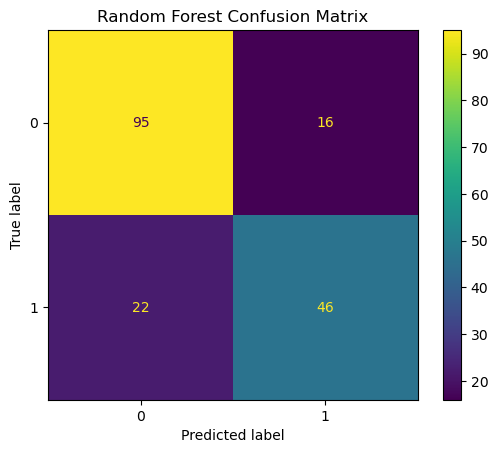

In [135]:
# confusion matrix of RF
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    best_clf,
    X_test_scaled,
    y_test_scaled
)

plt.title("Random Forest Confusion Matrix")
plt.savefig(
    "figures/confusion_matrix_RF.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [113]:
plt.gcf().savefig(
    "confusin_matrix_rf.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [96]:
# roc-auc
from sklearn.metrics import roc_auc_score

probabilities = best_clf.predict_proba(X_test_scaled)[:,1]

roc_auc = roc_auc_score(
    y_test_scaled,
    probabilities
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8734764175940647


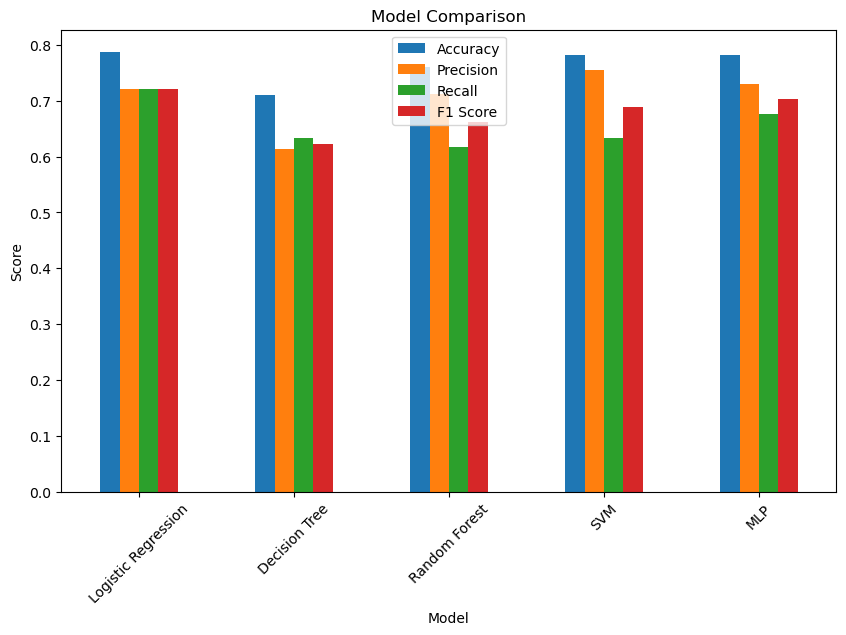

In [136]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.savefig(
    "figures/model_comaprison_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

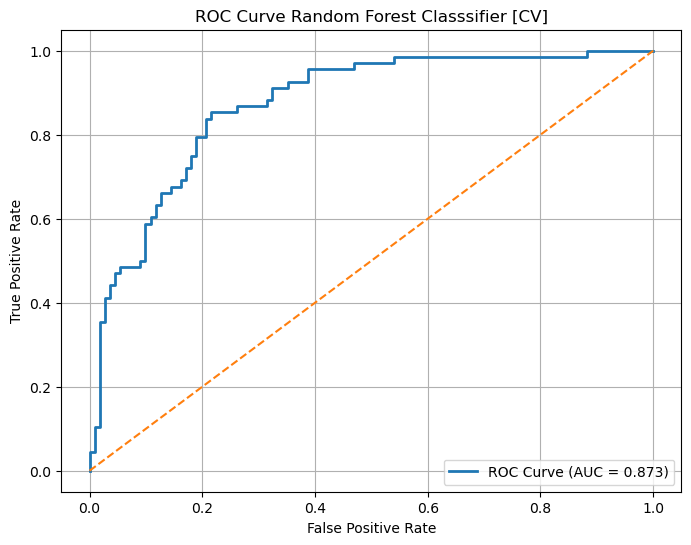

In [137]:
# Predicted probabilities
probabilities = best_clf.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_scaled, probabilities)

# Calculate AUC
roc_auc = roc_auc_score(y_test_scaled, probabilities)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {roc_auc:.3f})"
)

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Random Forest Classsifier [CV]")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(
    "figures/Roc_RF_CV.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

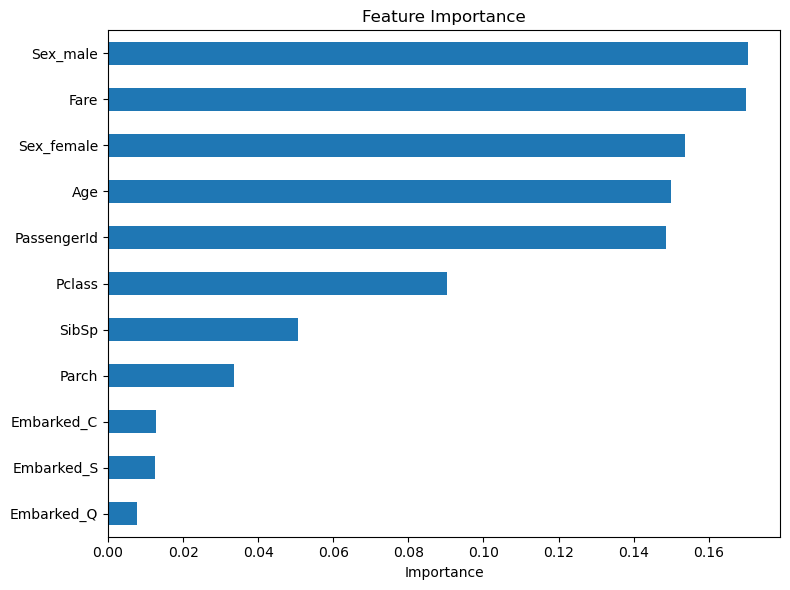

In [138]:
feature_importance = pd.Series(
    best_clf.feature_importances_,
    index=X.columns
).sort_values()

feature_importance.plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(
    "figures/feature_importance_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#  save the best model

In [103]:
import joblib

joblib.dump(best_clf, "best_model.pkl")

['best_model.pkl']